# END TO END PIPELINE — Adult Income Dataset (Classification)

**Goal:** Predict whether an individual's annual income exceeds $50K/yr using a Scikit-Learn Pipeline.

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pickle
import warnings
warnings.filterwarnings('ignore')

## Step 2 — Load Dataset

In [ ]:
df = pd.read_csv("adult.csv")
df.shape
df.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Step 3 — Basic Checks

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
# Replace "?" strings with NaN
df.replace("?", np.nan, inplace=True)
print("Null values after replacing ?:")
print(df.isnull().sum())

Null values after replacing ?:
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


## Step 4 — Exploratory Data Analysis

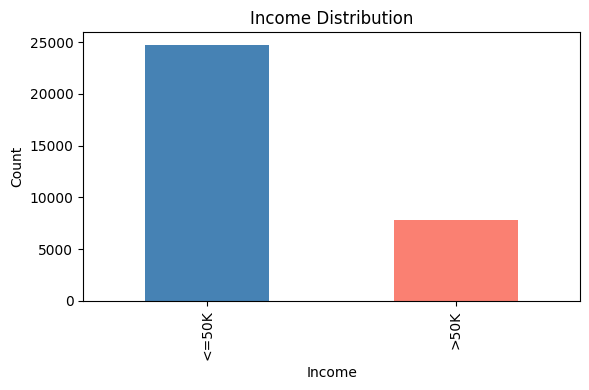

In [6]:
# Income Distribution
plt.figure(figsize=(6,4))
df['income'].value_counts().plot(kind='bar', color=['steelblue','salmon'])
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

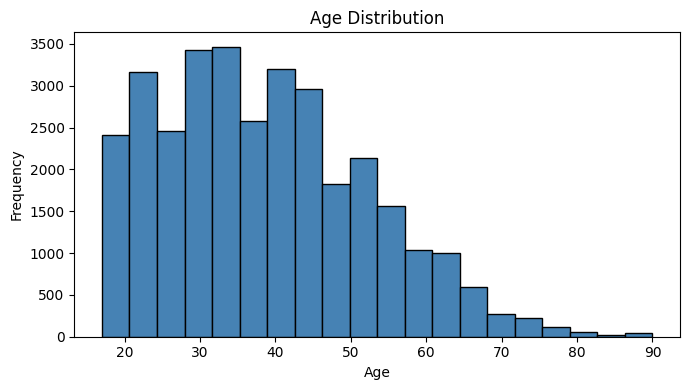

In [7]:
# Age Distribution
plt.figure(figsize=(7,4))
plt.hist(df['age'], bins=20, color='steelblue', edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

<Figure size 700x400 with 0 Axes>

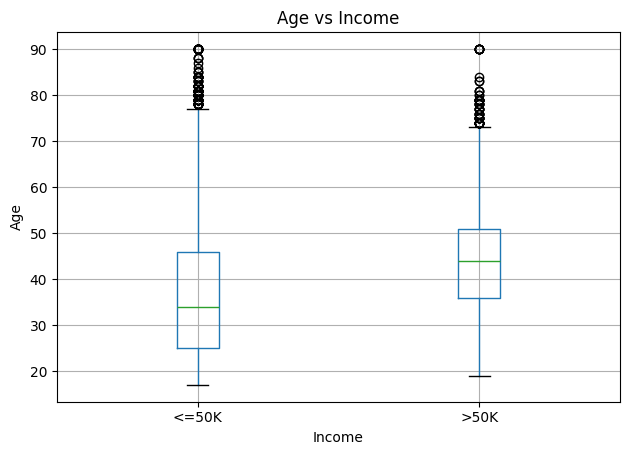

In [8]:
# Age vs Income (Boxplot)
plt.figure(figsize=(7,4))
df.boxplot(column='age', by='income')
plt.title("Age vs Income")
plt.suptitle("")
plt.xlabel("Income")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

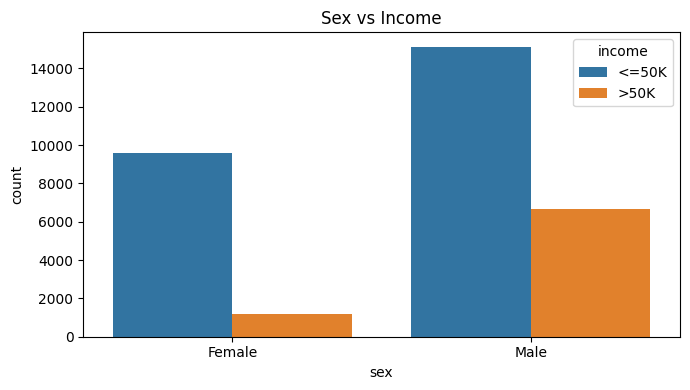

In [9]:
# Sex vs Income
plt.figure(figsize=(7,4))
sns.countplot(x='sex', hue='income', data=df)
plt.title("Sex vs Income")
plt.tight_layout()
plt.show()

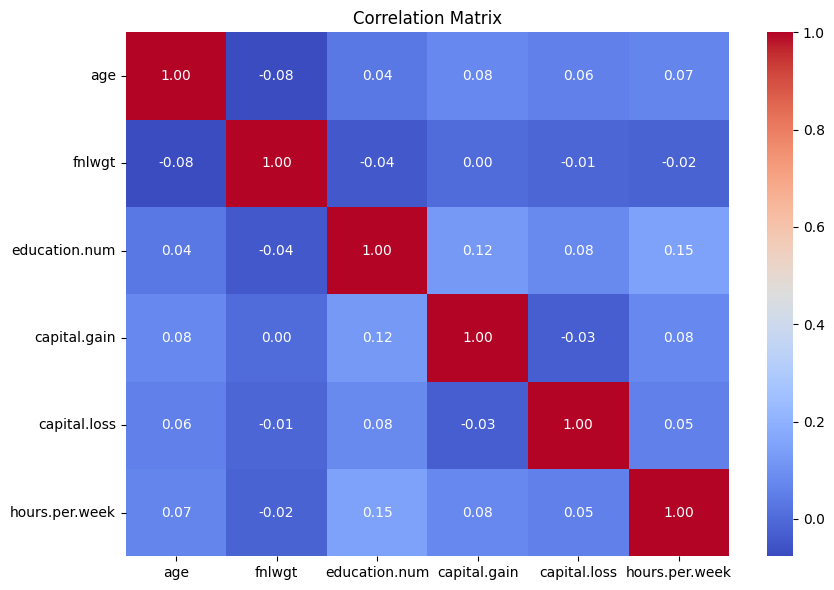

In [10]:
# Correlation Heatmap
num_cols = ["age","fnlwgt","education.num","capital.gain","capital.loss","hours.per.week"]
plt.figure(figsize=(9,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Step 5 — Preprocessing

In [11]:
# Remove duplicates
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (32537, 15)


In [12]:
# Encode target variable
df["income"] = df["income"].map({"<=50K": 0, ">50K": 1})
print(df["income"].value_counts())

income
0    24698
1     7839
Name: count, dtype: int64


In [13]:
# Outlier treatment on fnlwgt using IQR clipping
for _ in range(4):
    Q1 = df['fnlwgt'].quantile(0.25)
    Q3 = df['fnlwgt'].quantile(0.75)
    IQR = Q3 - Q1
    df['fnlwgt'] = df['fnlwgt'].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
print("Outlier treatment done.")

Outlier treatment done.


In [14]:
# Define features and target
X = df.drop("income", axis=1)
y = df["income"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (32537, 14)
Target shape: (32537,)


## Step 6 — Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (26029, 14)
Test size: (6508, 14)


## Step 7 — Build the Pipeline


In [16]:
# Identify column types
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Categorical columns: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']


In [ ]:
# Numerical pipeline: impute missing → scale
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Categorical pipeline: impute missing → ordinal encode
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

Preprocessor ready.


## Step 8 — Hyperparameter Tuning (Decision Tree)

In [18]:
# RandomizedSearchCV to find best Decision Tree params
param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__splitter": ["best", "random"],
    "model__max_depth": list(range(3, 12)),
    "model__min_samples_split": [2, 4, 6],
    "model__min_samples_leaf": list(range(1, 5))
}

dt_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

random_search = RandomizedSearchCV(
    dt_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)
print("Best Parameters:", random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'model__splitter': 'best', 'model__min_samples_split': 6, 'model__min_samples_leaf': 4, 'model__max_depth': 9, 'model__criterion': 'entropy'}


## Step 9 — Model Building with Best Parameters

In [ ]:
best_p = random_search.best_params_

best_dt_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DecisionTreeClassifier(
        criterion=best_p['model__criterion'],
        splitter=best_p['model__splitter'],
        max_depth=best_p['model__max_depth'],
        min_samples_split=best_p['model__min_samples_split'],
        min_samples_leaf=best_p['model__min_samples_leaf'],
        random_state=42
    ))
])

best_dt_pipeline.fit(X_train, y_train)

Best Decision Tree pipeline trained.


### Also build: Logistic Regression, Naive Bayes, KNN Pipelines

In [ ]:
# Logistic Regression pipeline
lr_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(penalty="l2", max_iter=500))
])
lr_pipeline.fit(X_train, y_train)

Logistic Regression pipeline trained.


In [ ]:
# Naive Bayes pipeline
nb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GaussianNB())
])
nb_pipeline.fit(X_train, y_train)

Naive Bayes pipeline trained.


In [23]:
# KNN pipeline (with GridSearchCV)
knn_param_grid = {
    "model__n_neighbors": [5, 7, 9],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

knn_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", KNeighborsClassifier())
])

knn_cv = GridSearchCV(knn_pipeline, knn_param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)
knn_cv.fit(X_train, y_train)
print("Best KNN params:", knn_cv.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best KNN params: {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'uniform'}


## Step 10 — Evaluation Metrics

In [24]:
results = {}

models = {
    "Decision Tree": best_dt_pipeline,
    "Logistic Regression": lr_pipeline,
    "Naive Bayes": nb_pipeline,
    "KNN": knn_cv.best_estimator_
}

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test, y_test_pred)
    f1        = f1_score(y_test, y_test_pred, average="micro")
    results[name] = {"Train Accuracy": round(train_acc,4),
                     "Test Accuracy": round(test_acc,4),
                     "F1 Score": round(f1,4)}
    print(f"{name}:")
    print(f"  Train Acc = {train_acc:.4f} | Test Acc = {test_acc:.4f} | F1 = {f1:.4f}")
    print()

Decision Tree:
  Train Acc = 0.8616 | Test Acc = 0.8579 | F1 = 0.8579

Logistic Regression:
  Train Acc = 0.8239 | Test Acc = 0.8261 | F1 = 0.8261

Naive Bayes:
  Train Acc = 0.8055 | Test Acc = 0.8069 | F1 = 0.8069

KNN:
  Train Acc = 0.8621 | Test Acc = 0.8337 | F1 = 0.8337



In [25]:
# Summary table
results_df = pd.DataFrame(results).T
print(results_df.to_string())

                     Train Accuracy  Test Accuracy  F1 Score
Decision Tree                0.8616         0.8579    0.8579
Logistic Regression          0.8239         0.8261    0.8261
Naive Bayes                  0.8055         0.8069    0.8069
KNN                          0.8621         0.8337    0.8337


In [26]:
# Classification Report for Best Model (Decision Tree)
y_pred_final = best_dt_pipeline.predict(X_test)
print("Classification Report — Decision Tree (Best Model):")
print(classification_report(y_test, y_pred_final, target_names=["<=50K", ">50K"]))

Classification Report — Decision Tree (Best Model):
              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.91      4988
        >50K       0.78      0.54      0.64      1520

    accuracy                           0.86      6508
   macro avg       0.83      0.75      0.78      6508
weighted avg       0.85      0.86      0.85      6508



## Step 11 — Save the Best Model

In [27]:
import pickle

with open("adult_income_best_model.pkl", "wb") as f:
    pickle.dump(best_dt_pipeline, f)

print("Best model pipeline saved as adult_income_best_model.pkl")

Best model pipeline saved as adult_income_best_model.pkl


## Step 12 — Load & Predict (Inference)

In [28]:
# Load model and predict on new data
with open("adult_income_best_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

# Example prediction on first 5 test samples
sample = X_test.iloc[:5]
predictions = loaded_model.predict(sample)
print("Predictions:", [">50K" if p==1 else "<=50K" for p in predictions])
print("Actuals:    ", [">50K" if p==1 else "<=50K" for p in y_test.iloc[:5].values])

Predictions: ['<=50K', '<=50K', '<=50K', '>50K', '>50K']
Actuals:     ['<=50K', '<=50K', '>50K', '>50K', '>50K']
